<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/Egg_White_Resist_E_Beam_Penetration_Monte_Carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

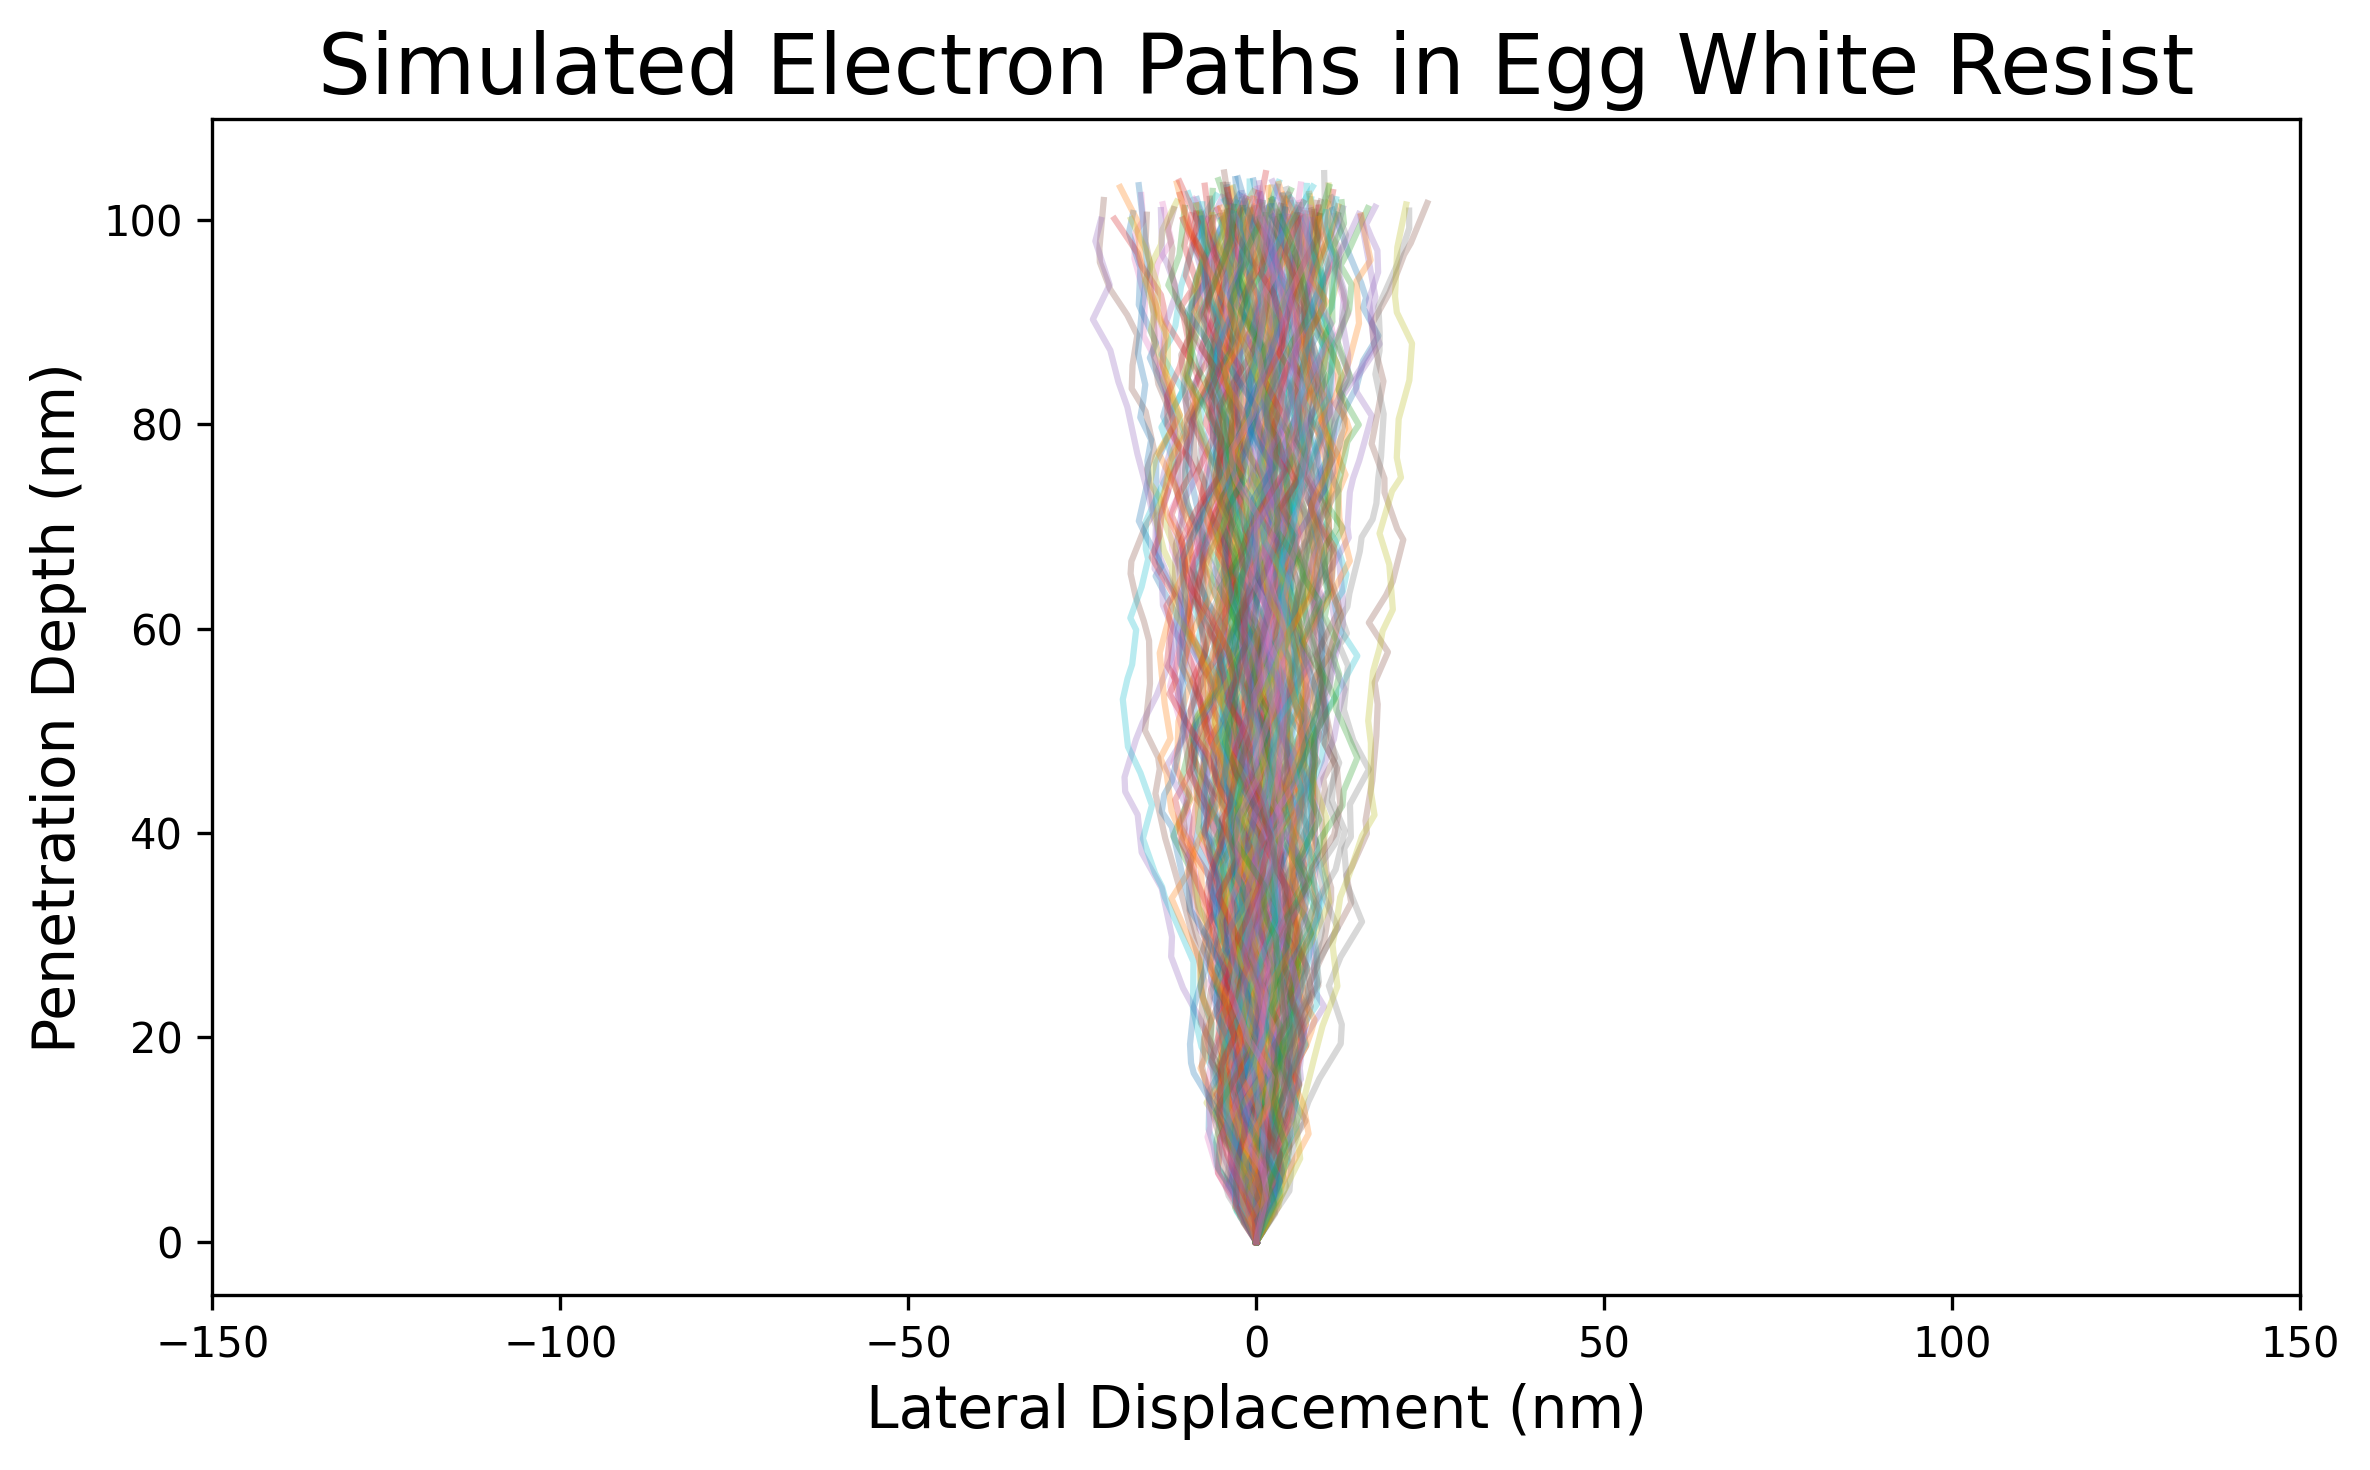

In [21]:
# Calculate a 100 keV electron-beam path in an egg white resist based on the paper found at https://onlinelibrary.wiley.com/doi/epdf/10.1002/admi.201601223
# Full-access paper title: 'Water-Based Photo- and Electron-Beam Lithography Using Egg White as a Resist'
# Monte Carlo simulation

import matplotlib.pyplot as plt
import numpy as np

# Constants
energy_keV = 100                 # Beam energy in keV
dose_uC_cm2 = 3000               # Beam dose in µC/cm² for positive pattern
thickness_nm = 100               # Resist thickness in nm
electron_charge = 1.602e-19      # Charge of an electron in Coulombs
area_cm2 = 1e-14                 # Area in cm² for single electron simulation

# Calculations for the number of electrons per area
dose_C_cm2 = dose_uC_cm2 * 1e-6   # Convert µC to C
num_electrons_per_cm2 = dose_C_cm2 / electron_charge

# Monte Carlo simulation parameters
num_electrons_simulated = int(num_electrons_per_cm2 * area_cm2)

# Define penetration depth function for the egg white resist
def simulate_electron_paths(num_electrons, energy_keV, thickness_nm):
    paths = []
    for _ in range(num_electrons):
        energy_remaining = energy_keV
        depth = 0.0
        path = {'x': [0.0], 'z': [0.0]}  # Start at origin
        while energy_remaining > 0.0 and depth < thickness_nm:
            scattering_angle = np.random.uniform(-np.pi/4, np.pi/4)
            step_length = np.random.uniform(1.0, 5.0)
            depth += step_length * np.cos(scattering_angle)
            lateral_displacement = step_length * np.sin(scattering_angle)
            path['x'].append(path['x'][-1] + lateral_displacement)
            path['z'].append(depth)
            energy_remaining -= 0.1 * step_length
        paths.append(path)
    return paths

# Run the simulation
electron_paths = simulate_electron_paths(num_electrons_simulated, energy_keV, thickness_nm)

# Plot the results with x-axis range [-150, 150]
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
for path in electron_paths:
    ax.plot(path['x'], path['z'], alpha=0.3)

# Set axis labels and title
ax.set_xlabel('Lateral Displacement (nm)', fontdict={'fontsize':14})
ax.set_ylabel('Penetration Depth (nm)', fontdict={'fontsize':14})
ax.set_title('Simulated Electron Paths in Egg White Resist', fontdict={'fontsize':20})

# Apply x-axis limits
ax.set_xlim(-150, 150)

plt.tight_layout()
plt.show()

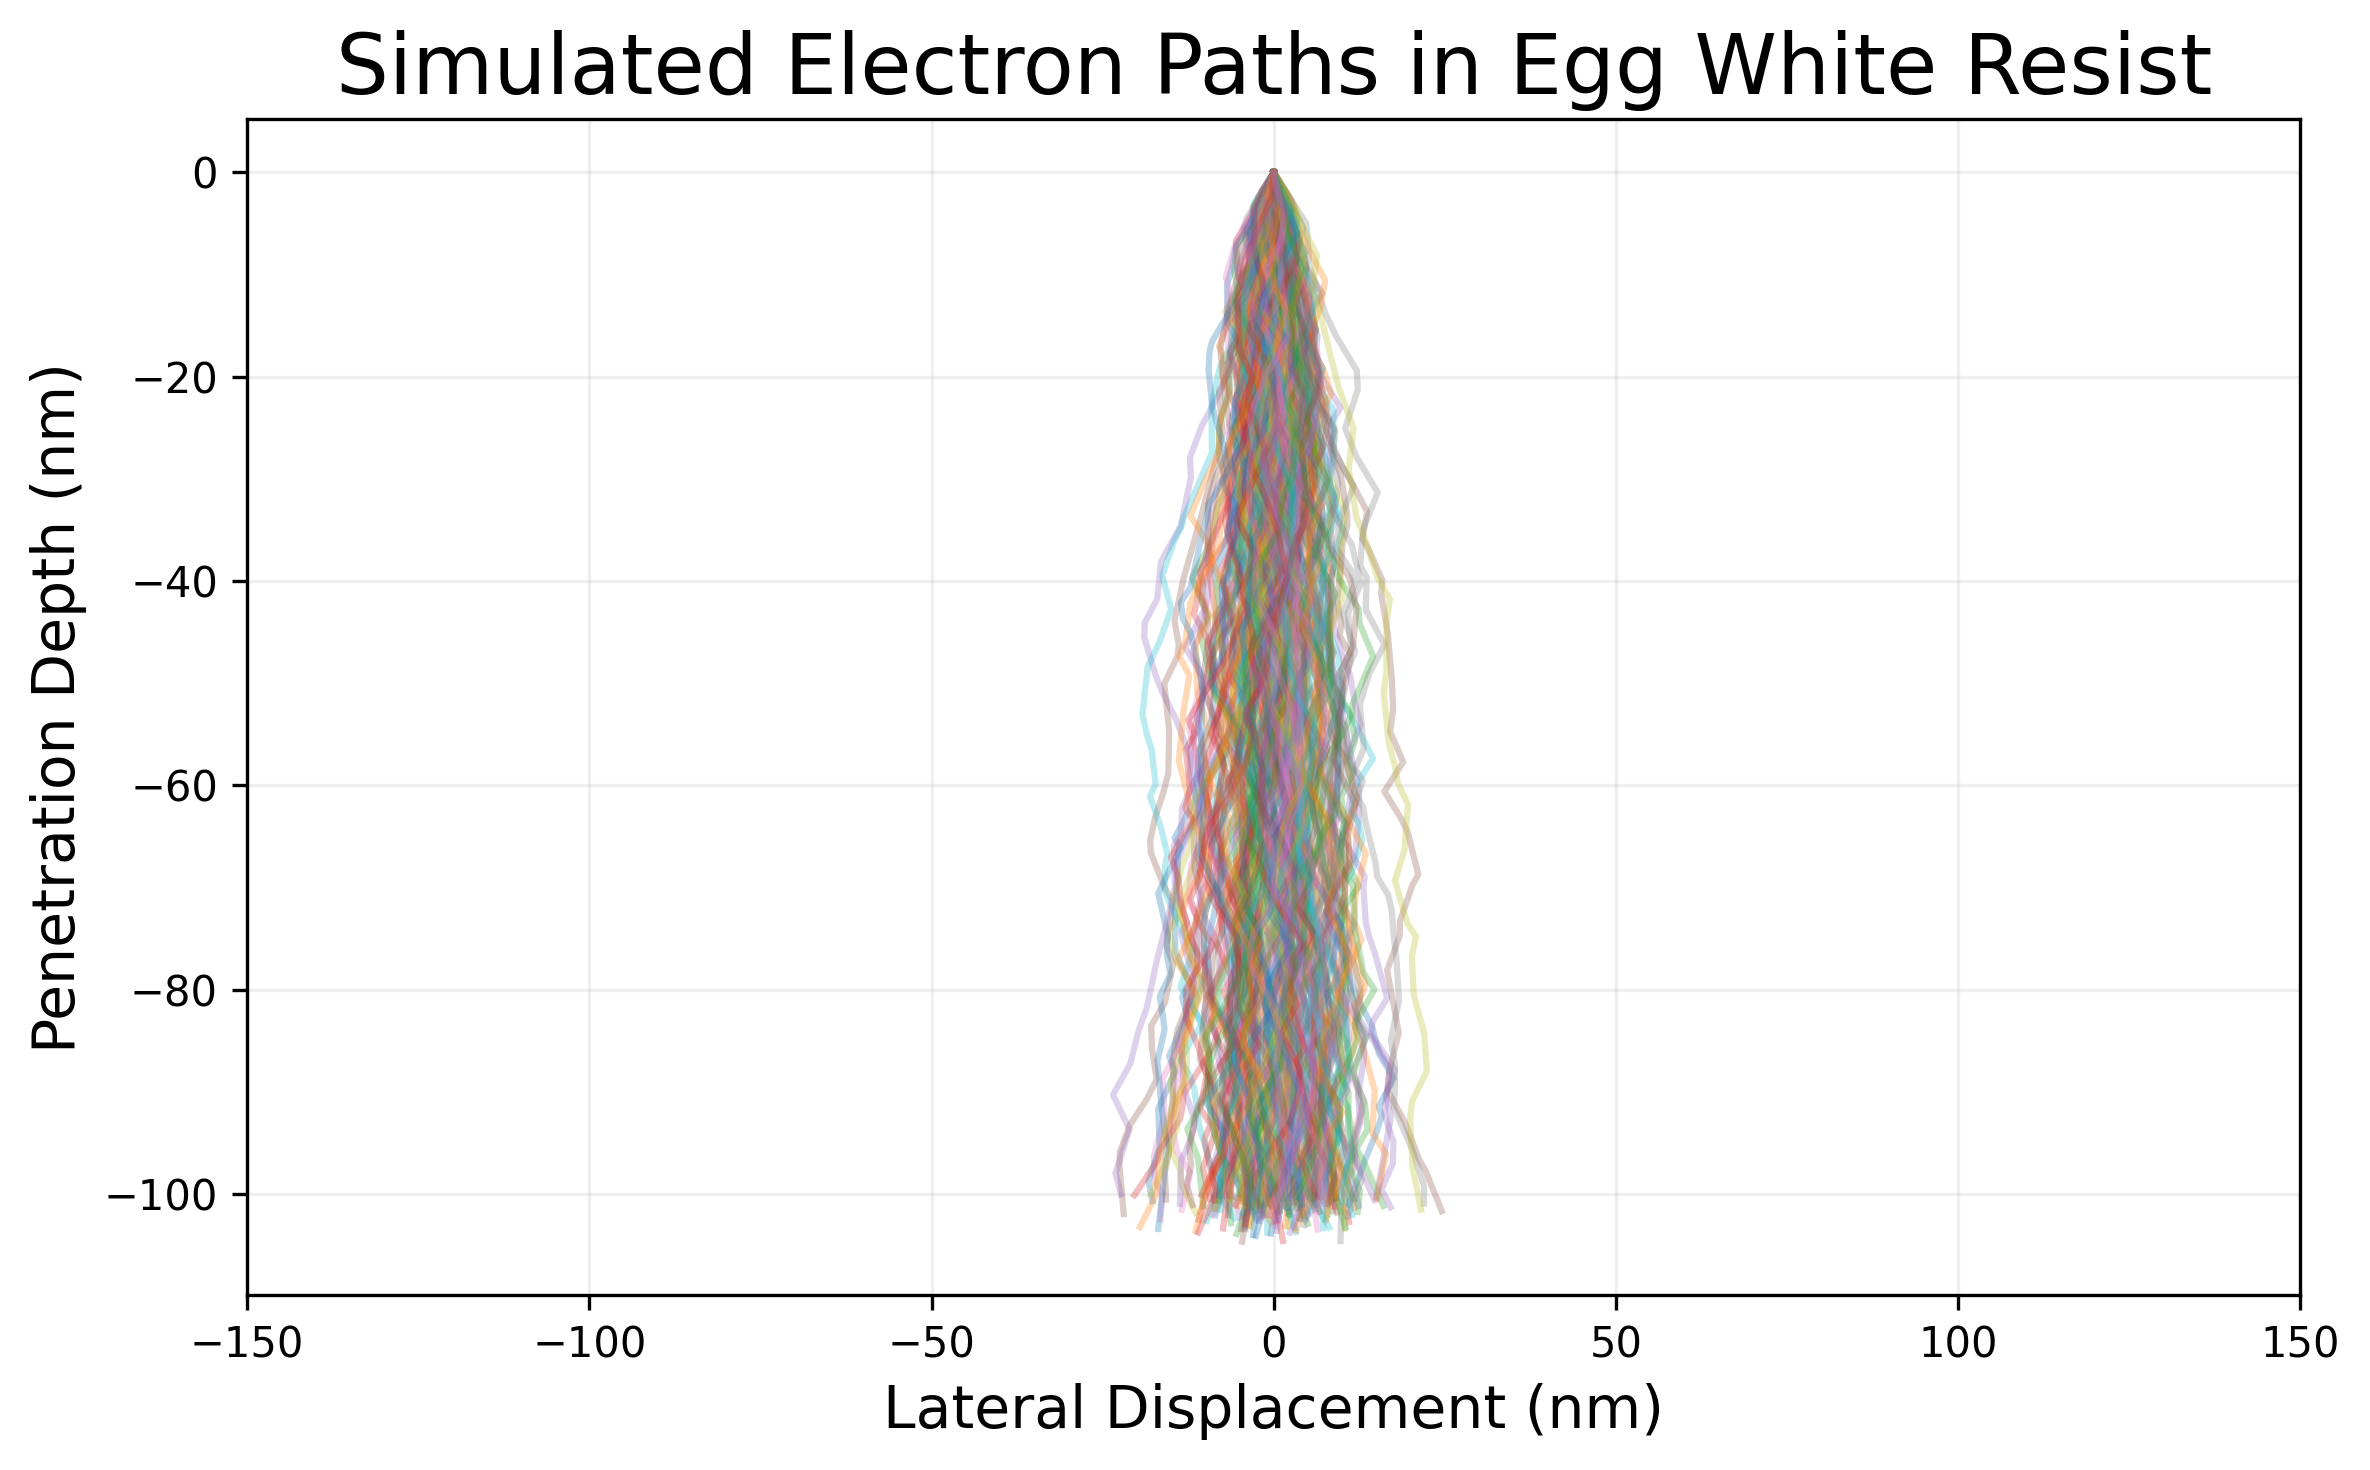

In [23]:
# Adjusted Plot Parameters for Electron Paths

import numpy as np
import matplotlib.pyplot as plt

# Assuming 'electron_paths' was already computed by simulate_electron_paths()
# and is a list of dicts with keys 'x' (list of lateral positions) and 'z' (list of depths).

# 1) Define the lateral displacement range (x-axis limits)
x_range_nm = (-150, 150)

# 2) Plot with custom sizes, fonts, and DPI
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
for path in electron_paths:
    # Optionally scale or shift the x-values if needed; here we plot directly
    ax.plot(path['x'], -np.array(path['z']), alpha=0.3)

# 3) Plot results with X-axis range set to (-150, 150)
x_range_nm = (-150, 150)

# 4) Customize labels and title
ax.set_xlabel('Lateral Displacement (nm)', fontsize=14)
ax.set_ylabel('Penetration Depth (nm)', fontsize=14)
ax.set_title('Simulated Electron Paths in Egg White Resist', fontsize=20)

# Apply x-axis limits
ax.set_xlim(-150, 150)

# 5) Show grid or any other aesthetic improvements if desired
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Simulating 187 electrons for a 250 nm resist thickness.


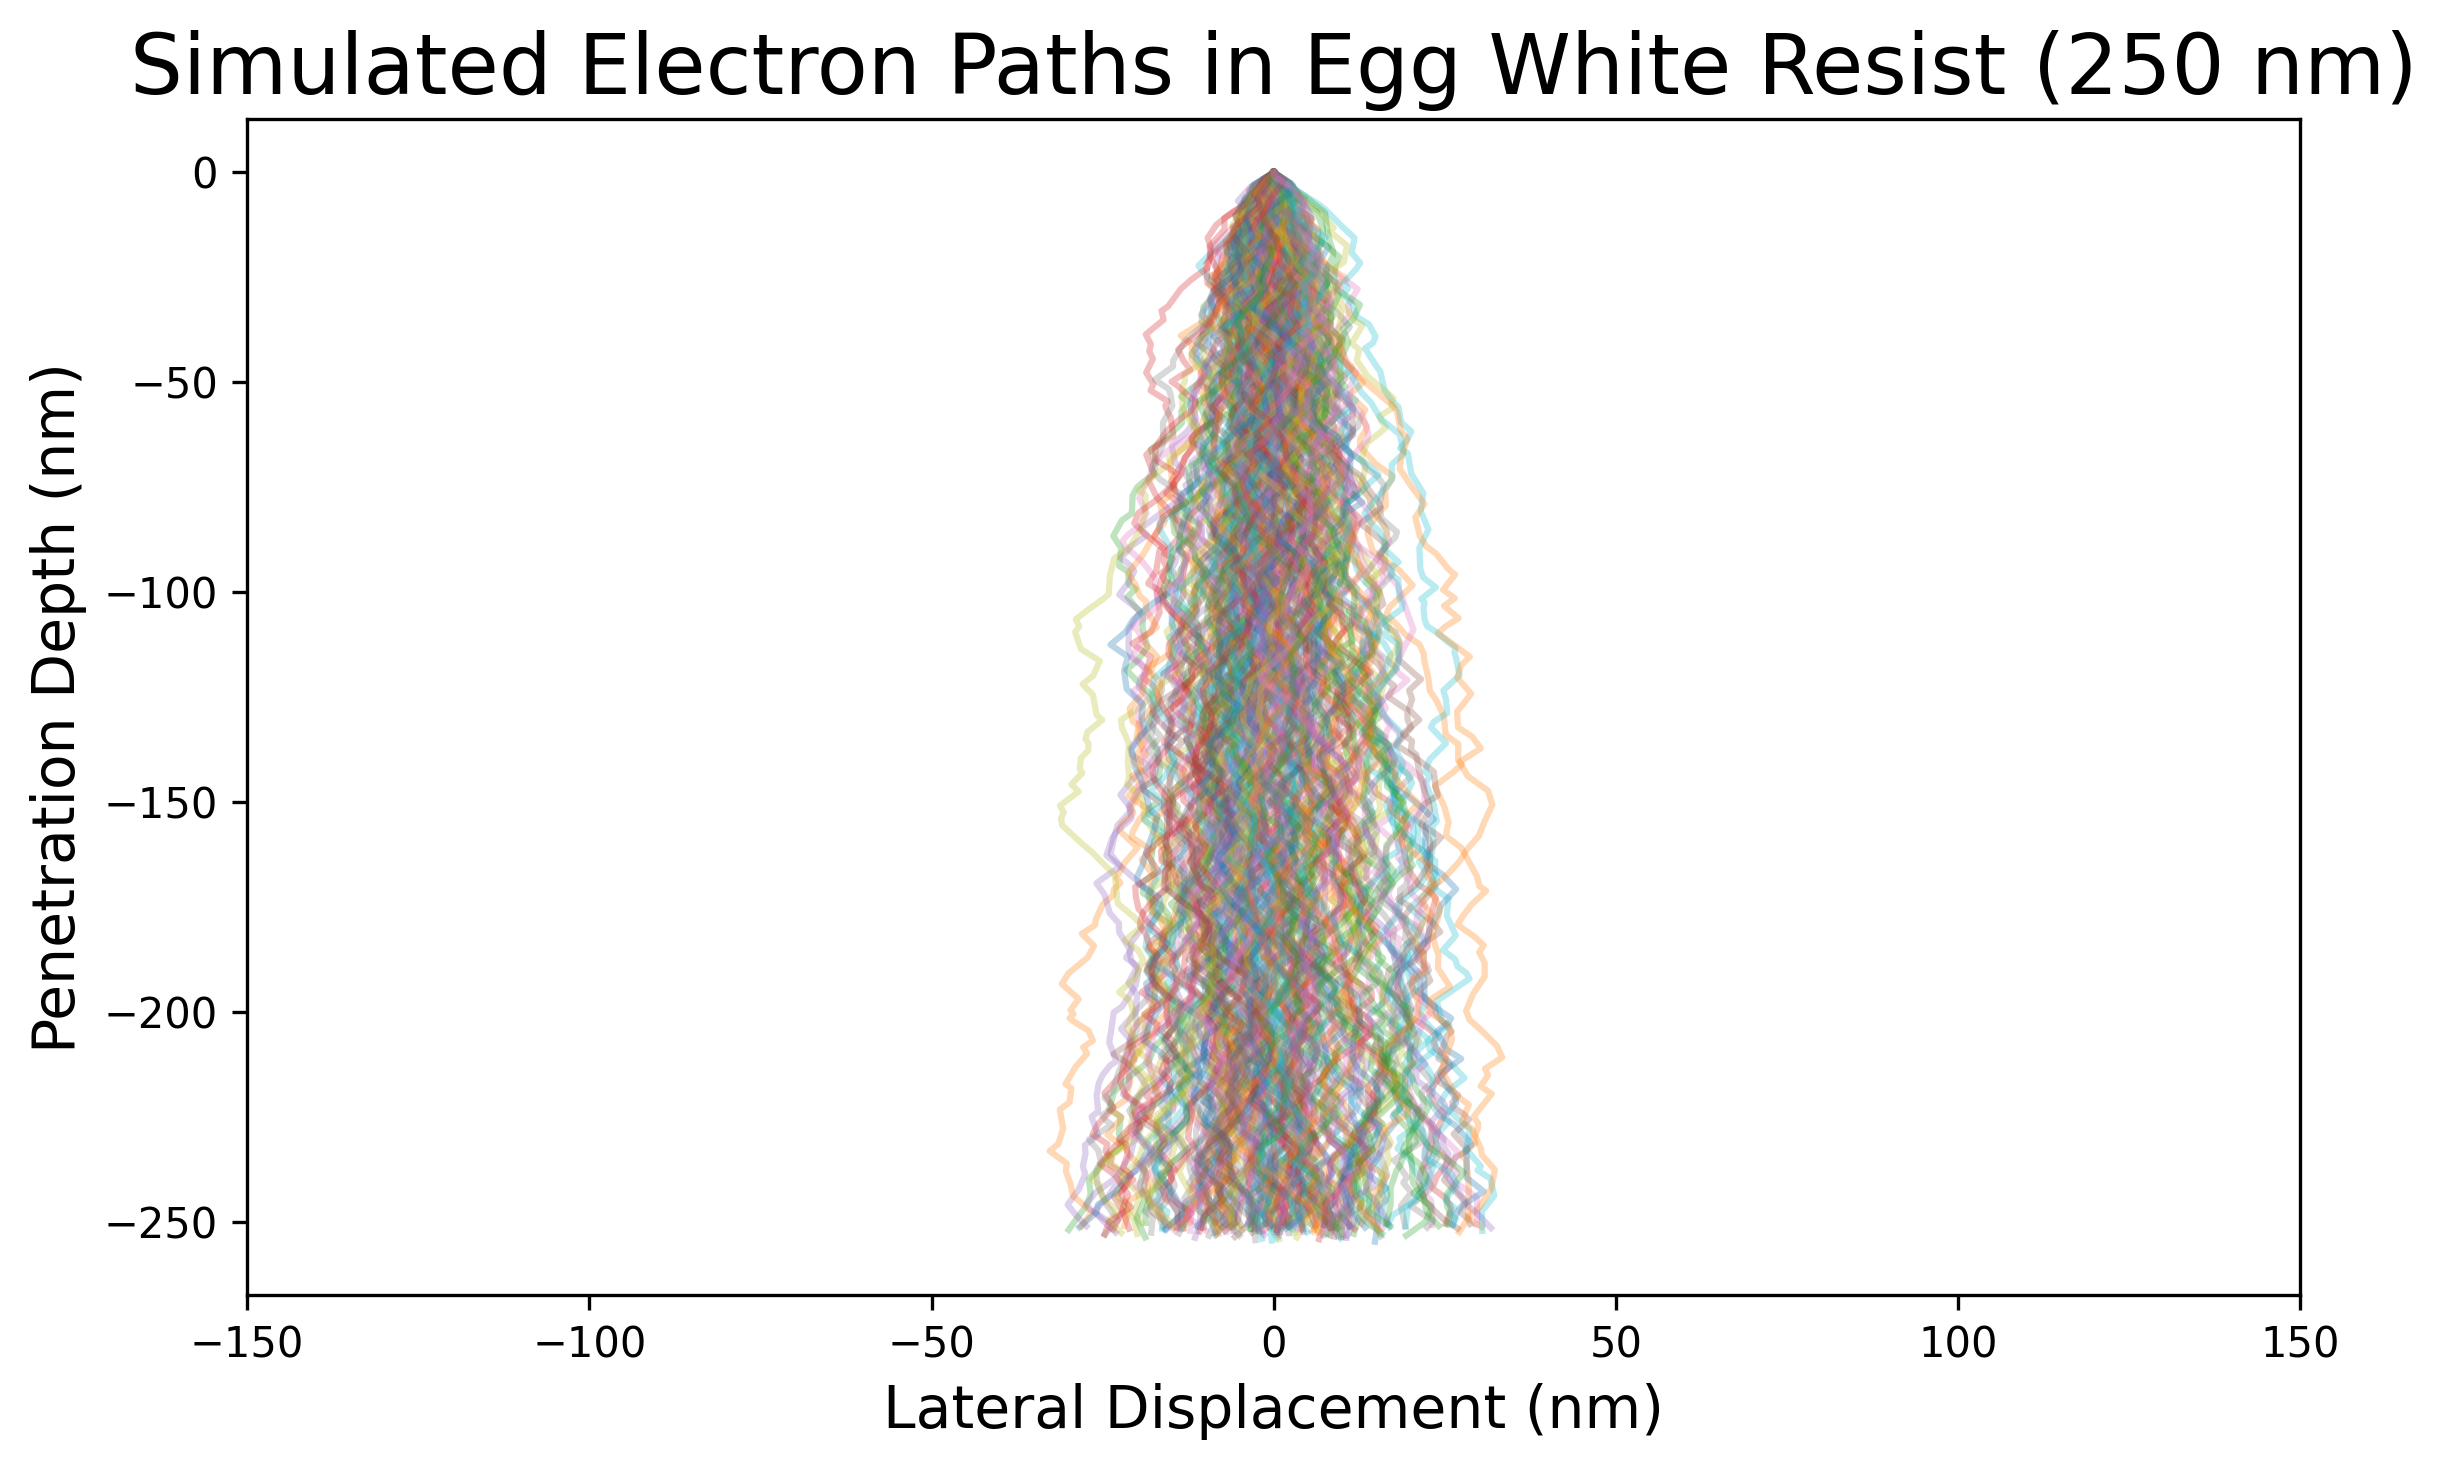

In [25]:
# ---------------------------------------------------------------
# Monte Carlo for 100 keV in 250 nm Resist with X-axis Adjusted
# ---------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# 1) Simulation parameters
energy_keV = 100              # Beam energy in keV
dose_uC_cm2 = 3000             # Beam dose in µC/cm²
thickness_nm = 250             # Resist thickness in nm
electron_charge = 1.602e-19    # Coulombs per electron
area_cm2 = 1e-14               # Simulation area in cm²

# 2) Calculate number of electrons in that area
dose_C_cm2 = dose_uC_cm2 * 1e-6
num_electrons_per_cm2 = dose_C_cm2 / electron_charge
num_electrons_simulated = int(num_electrons_per_cm2 * area_cm2)
print(f"Simulating {num_electrons_simulated} electrons for a 250 nm resist thickness.")

# 3) Penetration-depth Monte Carlo function (pure Python)
def simulate_electron_paths(num_electrons, energy_keV, thickness_nm):
    """
    Simulate each electron’s path until energy runs out or it exits the resist thickness.
    Returns a list of {'x': [...], 'z': [...]} dictionaries.
    """
    paths = []
    for _ in range(num_electrons):
        energy_remaining = energy_keV
        depth = 0.0
        path = {'x': [0.0], 'z': [0.0]}
        while energy_remaining > 0.0 and depth < thickness_nm:
            scattering_angle = np.random.uniform(-np.pi/4, np.pi/4)
            step_length = np.random.uniform(1.0, 5.0)
            depth += step_length * np.cos(scattering_angle)
            lateral_disp = step_length * np.sin(scattering_angle)
            path['x'].append(path['x'][-1] + lateral_disp)
            path['z'].append(depth)
            energy_remaining -= 0.1 * step_length
        paths.append(path)
    return paths

# 4) Run the simulation
electron_paths = simulate_electron_paths(num_electrons_simulated, energy_keV, thickness_nm)

# 5) Plot results with X-axis range set to (-150, 150)
x_range_nm = (-150, 150)

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
for path in electron_paths:
    ax.plot(path['x'], -np.array(path['z']), alpha=0.3)

ax.set_xlim(x_range_nm)
ax.set_xlabel('Lateral Displacement (nm)', fontsize=14)
ax.set_ylabel('Penetration Depth (nm)', fontsize=14)
ax.set_title('Simulated Electron Paths in Egg White Resist (250 nm)', fontsize=20)
plt.tight_layout()
plt.show()

Using device: cuda
Number of electrons: 187
CPU simulation time: 0.1217 s
GPU (PyTorch) simulation time: 0.0020 s


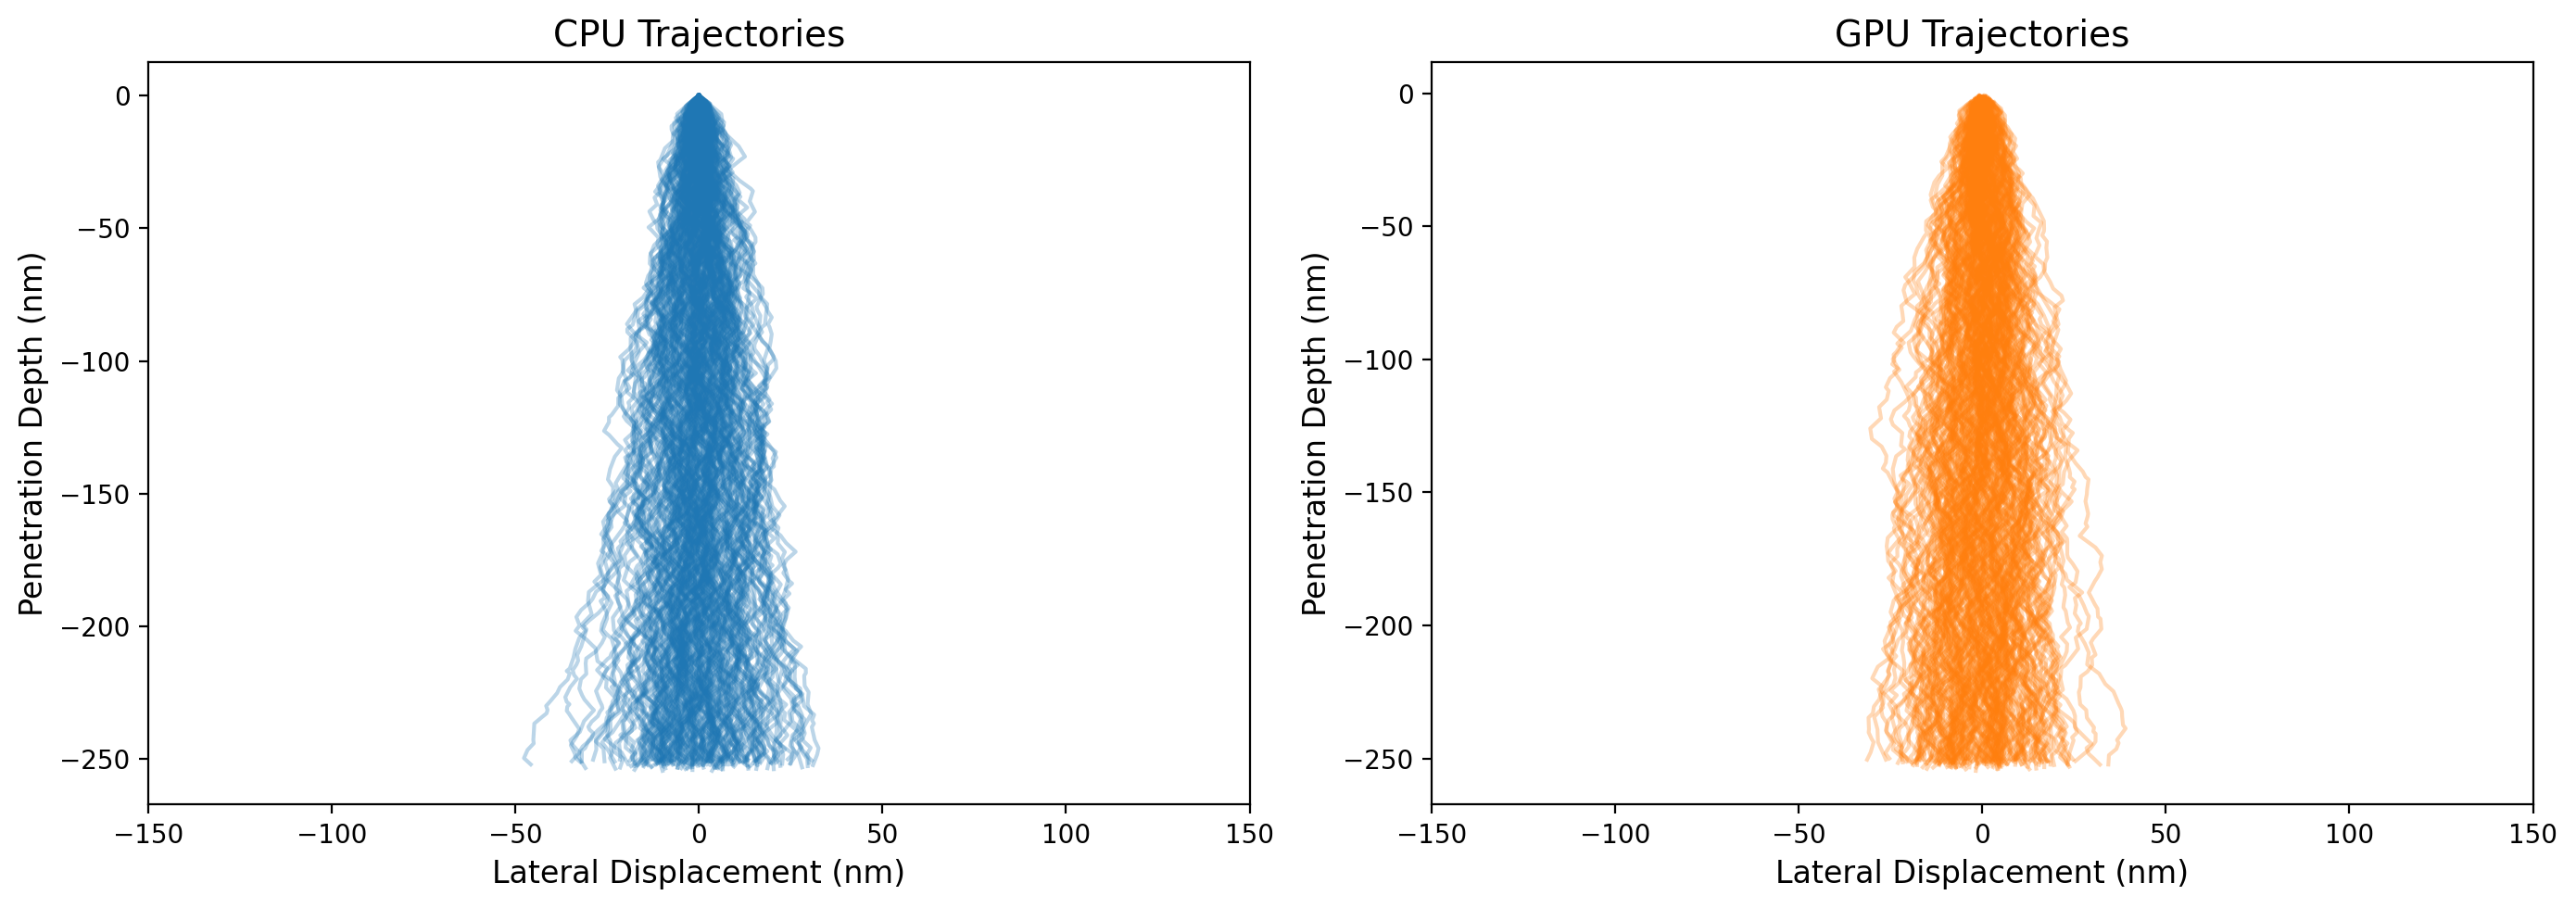

CPU time: 0.1217 s
GPU time: 0.0020 s
Speedup: 61.47×


In [11]:
# -----------------------------------------------
# CPU vs GPU Monte Carlo for 100 keV in 250 nm Resist (Adjusted X-axis)
# -----------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import time
import torch

# 1) Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 2) Problem parameters
energy_keV      = 100.0      # Beam energy in keV
thickness_nm    = 250.0      # Resist thickness in nm
dose_uC_cm2     = 3000.0     # Dose in µC/cm²
dose_C_cm2      = dose_uC_cm2 * 1e-6
electron_charge = 1.602e-19  # Coulombs per electron
area_cm2        = 1e-14      # Simulation area in cm²

# Compute how many electrons to simulate in that area
num_electrons_per_cm2 = dose_C_cm2 / electron_charge
num_electrons = int(num_electrons_per_cm2 * area_cm2)

# For a quick demo in Colab, clamp at ~20 000 electrons
num_electrons = min(num_electrons, 20000)
print(f"Number of electrons: {num_electrons}")

# ------------------------------------------------
# Part A: CPU Simulation (pure Python / NumPy loop)
# ------------------------------------------------
def simulate_electron_paths_cpu(num_electrons, energy_keV, thickness_nm):
    """
    For each electron, walk step-by-step until either:
      • energy ≤ 0  OR  depth ≥ thickness_nm.

    At each step:
      - Choose scattering_angle ∈ Uniform[-π/4, +π/4]
      - Choose step_length ∈ Uniform[1 nm, 5 nm]
      - depth += step_length * cos(scattering_angle)
      - lateral_disp = step_length * sin(scattering_angle)
      - energy_remaining -= 0.1 * step_length  (0.1 keV lost per nm)

    Returns a list of dictionaries, each with keys 'x' (1D array) and 'z' (1D array),
    tracing that electron’s (x, z) path until it stops or exits thickness.
    """
    paths = []
    for _ in range(num_electrons):
        energy_remaining = energy_keV
        depth = 0.0
        x_coords = [0.0]
        z_coords = [0.0]
        while energy_remaining > 0.0 and depth < thickness_nm:
            scattering_angle = np.random.uniform(-np.pi/4, np.pi/4)
            step_length = np.random.uniform(1.0, 5.0)
            depth += step_length * np.cos(scattering_angle)
            lateral_disp = step_length * np.sin(scattering_angle)
            x_coords.append(x_coords[-1] + lateral_disp)
            z_coords.append(depth)
            energy_remaining -= 0.1 * step_length
        paths.append({'x': np.array(x_coords), 'z': np.array(z_coords)})
    return paths

# Time the CPU version
start_cpu = time.time()
cpu_paths = simulate_electron_paths_cpu(num_electrons, energy_keV, thickness_nm)
end_cpu   = time.time()
cpu_time  = end_cpu - start_cpu
print(f"CPU simulation time: {cpu_time:.4f} s")


# ------------------------------------------------
# Part B: GPU Simulation (vectorized via PyTorch)
# ------------------------------------------------
# We will assume a safe upper‐bound of 400 steps per electron to reach 250 nm
max_steps = 400

# 1) Generate random angles and step lengths on GPU
#    shapes: (num_electrons, max_steps)
angles = (torch.rand((num_electrons, max_steps), device=device) * (np.pi/2) - (np.pi/4)).float()
steps  = (torch.rand((num_electrons, max_steps), device=device) * 4.0 + 1.0).float()

# 2) Compute per-step increments
delta_z      = steps * torch.cos(angles)       # depth increments (nm)
delta_x      = steps * torch.sin(angles)       # lateral increments (nm)
energy_loss  = 0.1 * steps                     # 0.1 keV lost per nm traveled

# Synchronize and start GPU timer
torch.cuda.synchronize()
start_gpu = time.time()

# 3) Cumulative sums along the “step” dimension
cum_z = torch.cumsum(delta_z, dim=1)         # (num_electrons, max_steps)
cum_x = torch.cumsum(delta_x, dim=1)
cum_energy_loss = torch.cumsum(energy_loss, dim=1)
cum_energy      = energy_keV - cum_energy_loss

# 4) Build a boolean mask: stop if (depth ≥ thickness) or (energy ≤ 0)
stop_mask = (cum_z >= thickness_nm) | (cum_energy <= 0)

# 5) Find first stopping index for each electron
stop_mask_f = stop_mask.float()                              # cast to float so argmax works
first_stop_idx = torch.argmax(stop_mask_f, dim=1)             # shape: (num_electrons,)
no_stop = (~stop_mask).all(dim=1)                             # True where electron never stops in ≤400 steps
first_stop_idx[no_stop] = max_steps - 1                        # clamp them to the last column

# 6) Now extract every electron’s trajectory from step 0 up to step first_stop_idx
idxs = torch.arange(num_electrons, device=device)
cum_x_cpu = cum_x.cpu().numpy()    # bring to host so we can easily slice in Python
cum_z_cpu = cum_z.cpu().numpy()
first_stop_idx_cpu = first_stop_idx.cpu().numpy()

gpu_paths = []
for i in range(num_electrons):
    L = first_stop_idx_cpu[i] + 1   # +1 to include that stopping step
    x_traj = cum_x_cpu[i, :L]
    z_traj = cum_z_cpu[i, :L]
    gpu_paths.append({'x': x_traj, 'z': z_traj})

torch.cuda.synchronize()
end_gpu = time.time()
gpu_time = end_gpu - start_gpu
print(f"GPU (PyTorch) simulation time: {gpu_time:.4f} s")


# ------------------------------------------------
# Part C: Plot CPU vs GPU trajectories side by side
#          (with custom X-axis range)
# ------------------------------------------------
x_range_nm = (-150, 150)  # X-axis limits for both plots

fig, axs = plt.subplots(1, 2, figsize=(14, 5), dpi=200)

# Plot CPU paths (flip z so depth grows downward)
for path in cpu_paths:
    axs[0].plot(path['x'], -path['z'], color='tab:blue', alpha=0.3)
axs[0].set_title('CPU Trajectories', fontsize=14)
axs[0].set_xlabel('Lateral Displacement (nm)', fontsize=12)
axs[0].set_ylabel('Penetration Depth (nm)', fontsize=12)
axs[0].set_xlim(x_range_nm)

# Plot GPU paths (flip z so depth grows downward)
for path in gpu_paths:
    axs[1].plot(path['x'], -path['z'], color='tab:orange', alpha=0.3)
axs[1].set_title('GPU Trajectories', fontsize=14)
axs[1].set_xlabel('Lateral Displacement (nm)', fontsize=12)
axs[1].set_ylabel('Penetration Depth (nm)', fontsize=12)
axs[1].set_xlim(x_range_nm)

plt.tight_layout()
plt.show()

# ------------------------------------------------
# Part D: Print timing summary
# ------------------------------------------------
print(f"CPU time: {cpu_time:.4f} s")
print(f"GPU time: {gpu_time:.4f} s")
print(f"Speedup: {cpu_time / gpu_time:.2f}×")

Using device: cuda
CPU generation time: 0.000479 s
GPU generation time: 0.018476 s
Speedup (CPU/GPU): 0.03×


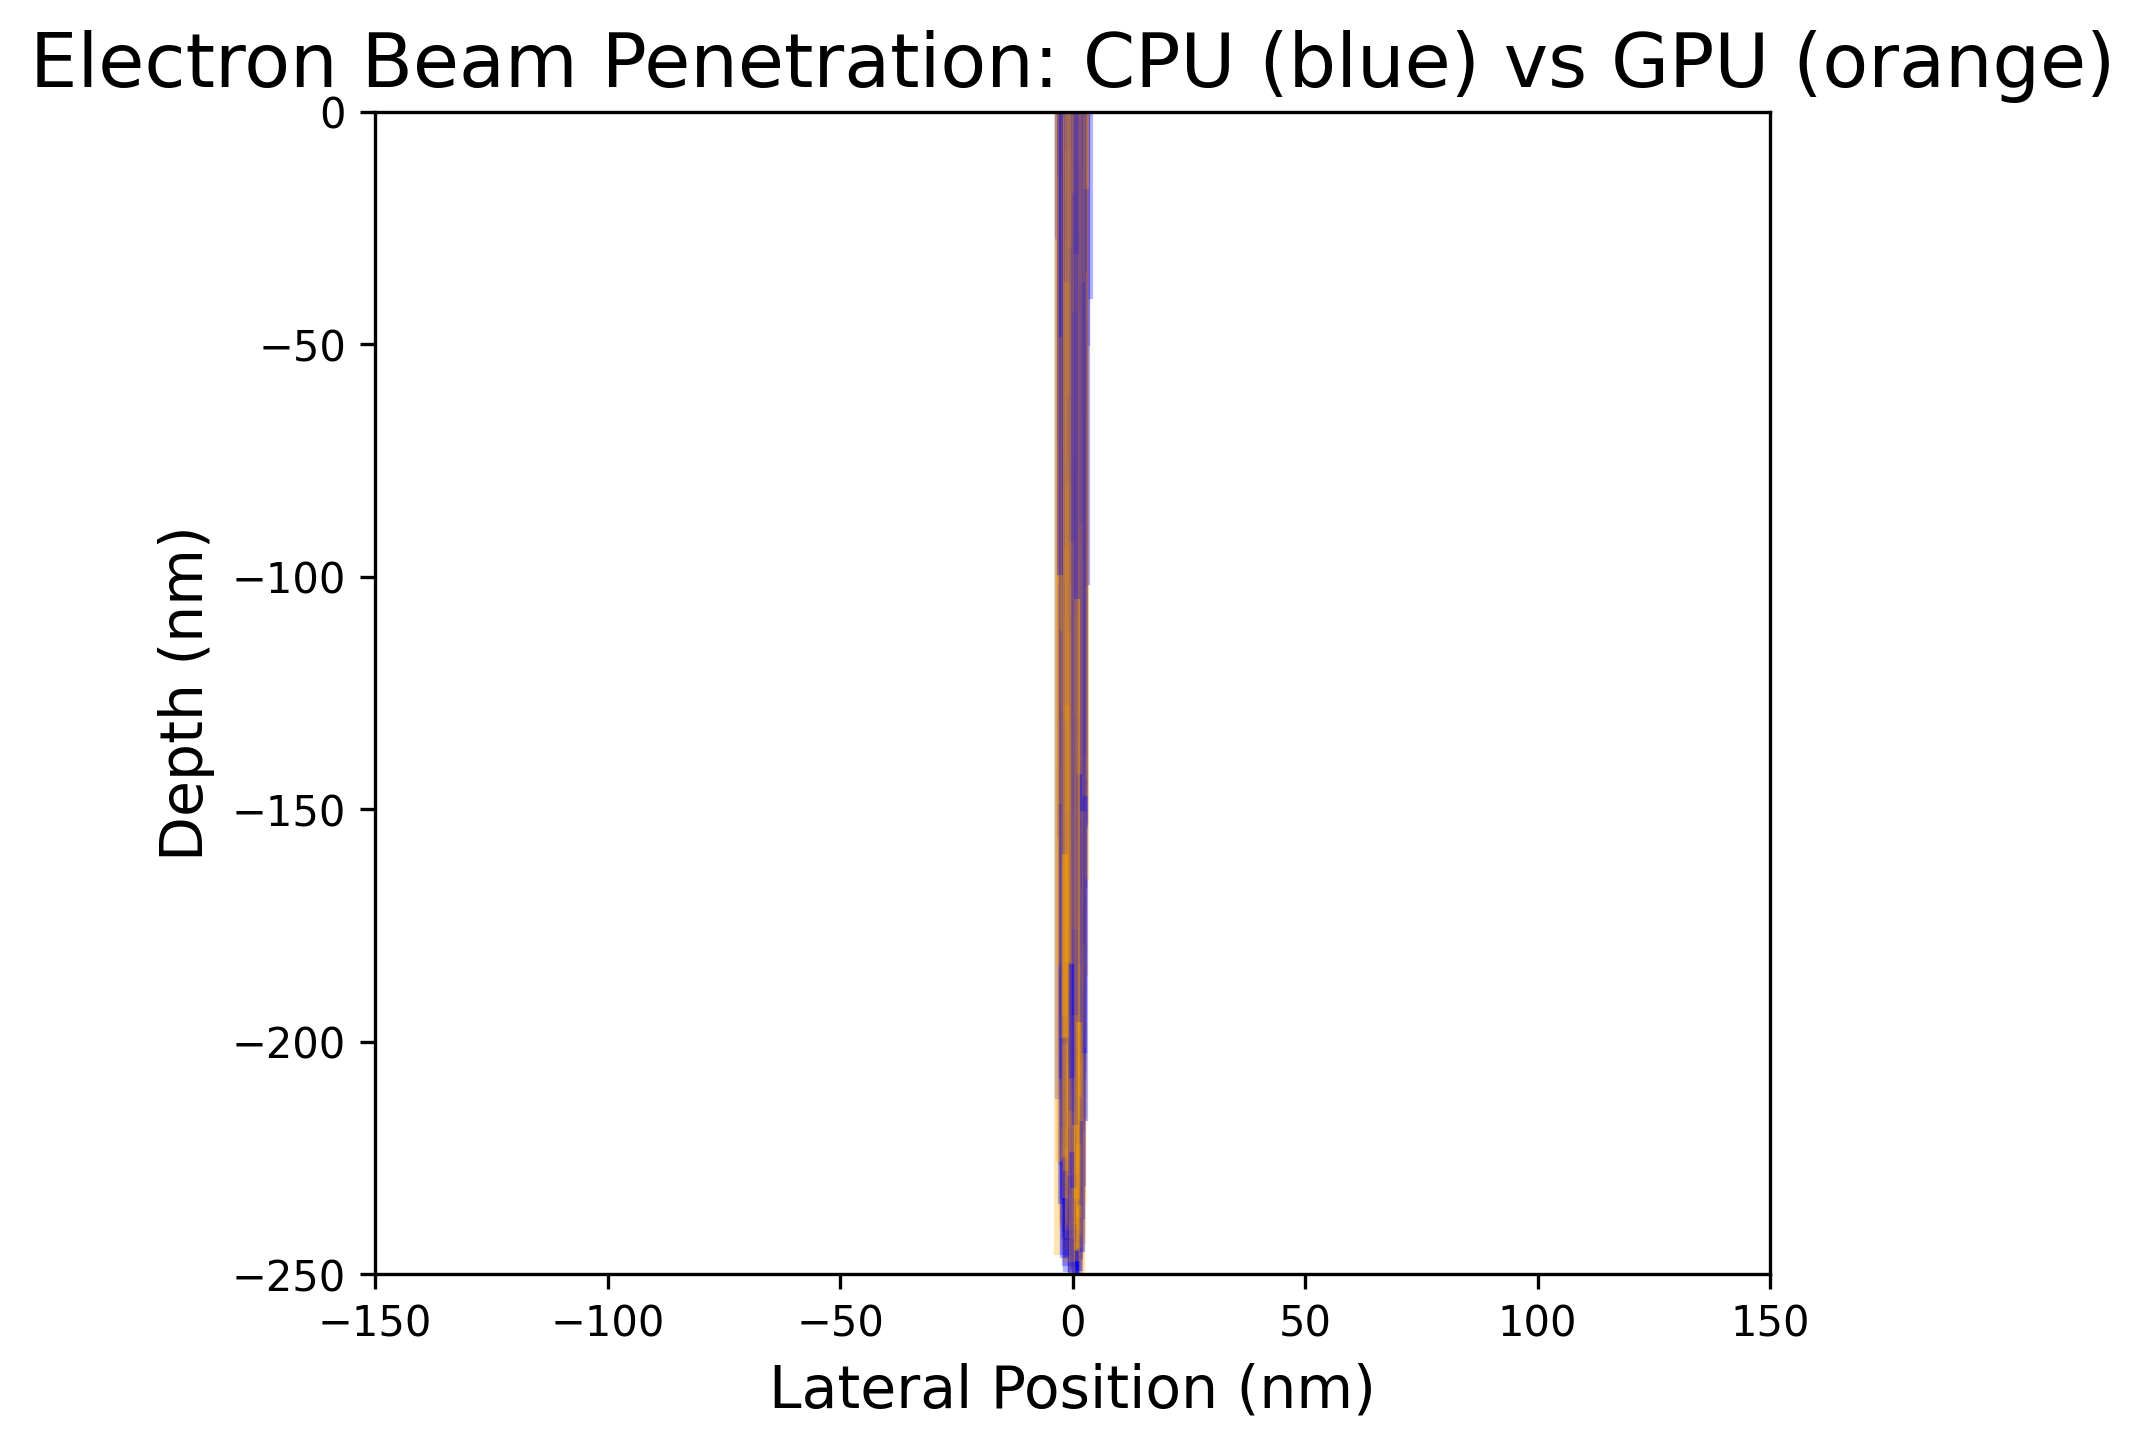

In [12]:
# ---------------------------------------------------------
# CPU vs GPU Generation of Electron Beam Paths (2 nm Spot, 250 nm Resist)
# ---------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import time
import torch

# 1) Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 2) Simulation parameters
electron_energy_keV       = 100.0    # keV (not directly used for path generation here)
beam_dose_uSv_per_cm2     = 3000.0   # µSv/cm² (for number_of_electrons calculation, not used below)
beam_spot_size_nm         = 2.0      # beam spot diameter in nm
resist_thickness_nm       = 250.0    # resist thickness in nm
x_range_nm                = (-150, 150)

# Monte Carlo parameters for demonstration
num_simulated_electrons   = 1000     # number of random paths to generate

# --------------------------------------------------
# Part A: CPU-based random path generation (NumPy)
# --------------------------------------------------
start_cpu = time.time()
# Depths: uniform(0, resist_thickness_nm)
depths_cpu = np.random.uniform(0.0, resist_thickness_nm, size=(num_simulated_electrons,))
# Lateral dispersion: Gaussian(0, sigma = beam_spot_size_nm/2)
sigma = beam_spot_size_nm / 2.0
x_disp_cpu = np.random.normal(0.0, sigma, size=(num_simulated_electrons,))
end_cpu = time.time()
cpu_time = end_cpu - start_cpu
print(f"CPU generation time: {cpu_time:.6f} s")

# --------------------------------------------------
# Part B: GPU-based random path generation (PyTorch)
# --------------------------------------------------
torch.cuda.synchronize()
start_gpu = time.time()
# Generate depths on GPU (uniform)
depths_gpu = torch.rand((num_simulated_electrons,), device=device) * resist_thickness_nm
# Generate lateral dispersion on GPU (normal with given sigma)
x_disp_gpu = torch.randn((num_simulated_electrons,), device=device) * sigma
# Transfer to CPU for plotting
depths_gpu_cpu = depths_gpu.cpu().numpy()
x_disp_gpu_cpu = x_disp_gpu.cpu().numpy()
torch.cuda.synchronize()
end_gpu = time.time()
gpu_time = end_gpu - start_gpu
print(f"GPU generation time: {gpu_time:.6f} s")

# Speedup (if GPU available)
if device.type == 'cuda':
    print(f"Speedup (CPU/GPU): {cpu_time / gpu_time:.2f}×")
else:
    print("GPU not available; generation only on CPU.")

# --------------------------------------------------
# Part C: Plotting the electron beam paths
# --------------------------------------------------
plt.figure(figsize=(6, 6), dpi=300)
for i in range(num_simulated_electrons):
    # CPU paths in light blue
    plt.plot([x_disp_cpu[i], x_disp_cpu[i]], [0, -depths_cpu[i]], 'b', alpha=0.3)
    # GPU paths in orange overlay
    plt.plot([x_disp_gpu_cpu[i], x_disp_gpu_cpu[i]], [0, -depths_gpu_cpu[i]], 'orange', alpha=0.3)

# Set plot limits and labels
plt.xlim(x_range_nm)
plt.ylim(-resist_thickness_nm, 0)
plt.xlabel('Lateral Position (nm)', fontsize=14)
plt.ylabel('Depth (nm)', fontsize=14)
plt.title('Electron Beam Penetration: CPU (blue) vs GPU (orange)', fontsize=18)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()